# Sampling

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import numpy as np

import matplotlib.pyplot as plt

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [7,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

## Inversion Sampling

Draw uniformly distributed random numbers and assume those correspond to the cumulated probability, which can be inverted to reproduce the underlying density distribution that we want to sample from.

### Salpeter Initial Mass Function

Our probability density function over $m \in [m_1, m_2]$ is given by

$$p(m) \propto m^{-\alpha}$$

with a corresponding cumulative distribution function

$$P(m) \propto \frac{m^{1-\alpha} - m_1^{1-\alpha}}{1-\alpha}$$

that must fulfill $P(m_1) = 0$ and $P(m_2) = 1$ per definition. From integrating or simply by reading off, we find

$$\frac{m_2^{1-\alpha} - m_1^{1-\alpha}}{1-\alpha}$$

as the normalization constant, yielding

$$P(m, m_1, m_2) = \frac{m^{1-\alpha} - m_1^{1-\alpha}}{m_2^{1-\alpha} - m_1^{1-\alpha}}$$

for the cumulated distribution. Accordingly, its density is given by

$$p(m, m_1, m_2) = \frac{d}{dm} P(m, m_1, m_2) = \frac{(1-\alpha)m^{-\alpha}}{m_2^{1-\alpha} - m_1^{1-\alpha}}$$

where $m_1 < m_2$ is implied. Inversion of $P(m)$ turns out to be

$$m(P, m_1, m_2) = \left(P (m_2^{1-\alpha} - m_1^{1-\alpha}) +  m_1^{1-\alpha}\right)^{1/(1-\alpha)}$$

and represents the mass distribution. Numerical test parameters:

$$\begin{aligned}
m_1 = 0.1 \,M_\odot && m_2 = 100 \,M_\odot && \alpha = 2.3 && n = 10^6
\end{aligned}$$

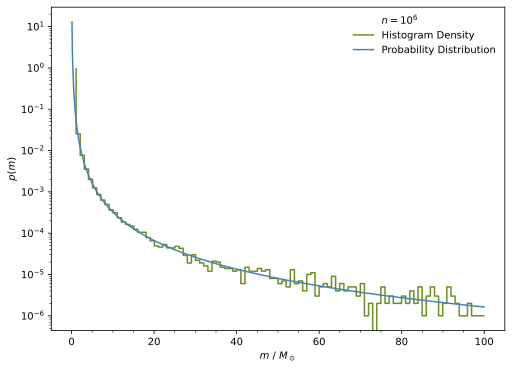

In [2]:
rng = np.random.default_rng(0)

m1 = 0.1
m2 = 100

a = 2.3

n = 10**6

P = rng.uniform(0, 1, n)

m = (P * (m2**(1-a) - m1**(1-a)) + m1**(1-a))**(1/(1-a))

plt.plot([], [], 'none', label=f'$n = 10^{{{np.log10(n):.0f}}}$')

hist, edge = np.histogram(m, bins=100, density=True)
edge = edge[1:]

plt.step(edge, hist, label='Histogram Density')

x = np.linspace(m1, m2, 1000)
y = (1-a) * x**(-a) / (m2**(1-a) - m1**(1-a))

plt.plot(x, y, label='Probability Distribution')

plt.xlabel(r'$m$ / $M_\odot$')
plt.ylabel(r'$p(m)$')

plt.yscale('log')

plt.legend()

plt.show()
plt.close()

### Box-Muller / Marsaglia Polar Method

Since the normal distribution cannot directly be integrated and inverted, we can write it in two dimensions as

$$p(x)dx \: p(y)dy = \frac{1}{2\pi\sigma^2} \, \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right) dx\,dy =
\frac{1}{2\pi\sigma^2} \, \exp\left(-\frac{r^2}{2\sigma^2}\right) r dr \, d\varphi = p(r)p(\varphi) dr d\varphi$$

where we change from cartesian to polar coordinates. We then find

$$P_1(r) = 1 - \exp\left( -\frac{r^2}{2\sigma^2} \right)$$

with $r \in [0, \infty)$ and

$$P_2(\varphi) = \frac{\varphi}{2\pi}$$

with $\varphi \in [0, 2\pi]$ as domains. Inverting yields

$$r(P_1) = \sqrt{-2\sigma^2\ln(1 - P_1)}$$

as well as

$$\varphi(P_2) = 2\pi P_2$$

with $P_2 \sim \mathcal{U}(0, 1)$ and since from $P_1 \sim \mathcal{U}(0, 1)$ follows that also $1 - P_1 \sim \mathcal{U}(0, 1)$ we can replace $1 - P_1$ with $P_1$ and obtain independent variables

$$x(P_1, P_2) = r(P_1) \cos\bigl(\varphi(P_2)\bigr) = \sqrt{-2\sigma^2\ln(P_1)}\cos(2\pi P_2)$$
$$y(P_1, P_2) = r(P_1) \sin\bigl(\varphi(P_2)\bigr) = \sqrt{-2\sigma^2\ln(P_1)}\sin(2\pi P_2)$$

that follow a Gaussian distribution.

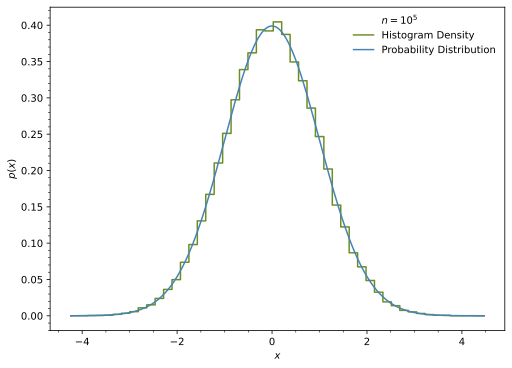

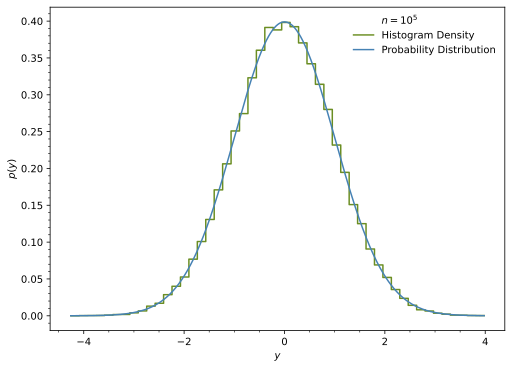

In [3]:
n = 10**5

P1 = rng.uniform(0, 1, n)
P2 = rng.uniform(0, 1, n)

valX = np.sqrt(-2 * np.log(P1)) * np.cos(2*np.pi * P2)
valY = np.sqrt(-2 * np.log(P1)) * np.sin(2*np.pi * P2)

plt.plot([], [], 'none', label=f'$n = 10^{{{np.log10(n):.0f}}}$')

hist, edge = np.histogram(valX, bins=50, density=True)
edge = edge[1:]

plt.step(edge, hist, label='Histogram Density')

x = np.linspace(edge[0], edge[-1], 1000)
y = np.exp(-x**2 / 2) / np.sqrt(2*np.pi)

plt.plot(x, y, label='Probability Distribution')

plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')

plt.legend()

plt.show()
plt.close()

plt.plot([], [], 'none', label=f'$n = 10^{{{np.log10(n):.0f}}}$')

hist, edge = np.histogram(valY, bins=50, density=True)
edge = edge[1:]

plt.step(edge, hist, label='Histogram Density')

x = np.linspace(edge[0], edge[-1], 1000)
y = np.exp(-x**2 / 2) / np.sqrt(2*np.pi)

plt.plot(x, y, label='Probability Distribution')

plt.xlabel(r'$y$')
plt.ylabel(r'$p(y)$')

plt.legend()

plt.show()
plt.close()

## Rejection Sampling

Use inversion sampling to draw from a majorant function that envelops the target distribution and is therefore not a proper probability density since it cannot be normalized, then draw uniformly distributed random numbers between zero and the enveloping function, and accept the sample only as such when it lies below the searched for function, otherwise reject it.

### Gaussian Distribution

We can define the constant enveloping function

$$f(s) = 1$$

with $s \in [-25, 25]$ and

$$F(s) = s + 25$$

leading to

$$s(F) = F - 25$$

where since $F \sim \mathcal{U}(0, 50)$ we can also use $s \sim \mathcal{U}(-25, 25)$ as an equivalent formulation. Now draw

$$t(s) \sim \mathcal{U}\bigl(0, f(s)\bigr)$$

and compare to the target

$$p(s) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{s^2}{2\sigma^2}\right)$$

and decide via

$$\begin{cases} s \sim p(s) & t(s) \leq p(s) \\ s \nsim p(s) & t(s) > p(s) \end{cases}$$

whether the sample belongs to it.

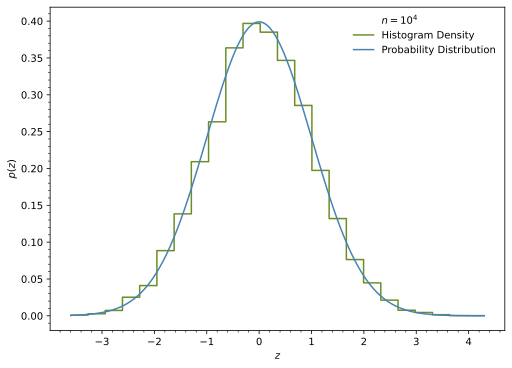

In [4]:
z = np.array([])

n = 10**4

while len(z) < n:
    s = rng.uniform(-25, 25)
    t = rng.uniform(0, 1)
    if t <= np.exp(-s**2 / 2) / np.sqrt(2*np.pi):
        z = np.append(z, s)

plt.plot([], [], 'none', label=f'$n = 10^{{{np.log10(n):.0f}}}$')

hist, edge = np.histogram(z, bins=25, density=True)
edge = edge[1:]

plt.step(edge, hist, label='Histogram Density')

x = np.linspace(edge[0], edge[-1], 1000)
y = np.exp(-x**2 / 2) / np.sqrt(2*np.pi)

plt.plot(x, y, label='Probability Distribution')

plt.xlabel(r'$z$')
plt.ylabel(r'$p(z)$')

plt.legend()

plt.show()
plt.close()